In [56]:
import torch

## Exact same copy from Slack

def compute_distances(A: torch.Tensor, ground_truth: torch.Tensor, 
                        method="zscore"):
    """
    Compute row-wise Euclidean distances between A (N, D) and ground_truth (1, D),
    with optional normalization.

    Args:
        A: Tensor of shape (N, D)
        ground_truth: Tensor of shape (1, D)
        method: "zscore", "minmax", or None

    Returns:
        distances: Tensor of shape (N,)
    """
    if method == "zscore":
        mean = A.mean(dim=0, keepdim=True)
        std = A.std(dim=0, keepdim=True)
        A = (A - mean) / std
        ground_truth = (ground_truth - mean) / std

    elif method == "minmax":
        minv = A.min(dim=0, keepdim=True).values
        maxv = A.max(dim=0, keepdim=True).values
        A = (A - minv) / (maxv - minv)
        ground_truth = (ground_truth - minv) / (maxv - minv)

    # Euclidean distance row-wise
    distances = torch.norm(A - ground_truth, p=2, dim=1)
    return distances

In [57]:
# GT

thickness = 380 # Ang
tilt_x = 1.5 # mrad
tilt_y = -1.5 # mrad

GT = torch.tensor([thickness, tilt_x, tilt_y])
GT

tensor([380.0000,   1.5000,  -1.5000])

In [58]:
# Methods

BO_thickness_offset = -100
BO_thickness_std = 100

BO_tilt_x_offset = 0.5
BO_tilt_x_std = 0.5

BO_tilt_y_offset = -0.5
BO_tilt_y_std = 0.5


# Just 2 order better
BOCF_thickness_offset = -1
BOCF_thickness_std = 1

BOCF_tilt_x_offset = 0.005
BOCF_tilt_x_std = 0.005

BOCF_tilt_y_offset = -0.005
BOCF_tilt_y_std = 0.005


In [59]:
N = 1000

BO_thickness = torch.randn((N,1)) * BO_thickness_std + thickness + BO_thickness_offset
BO_tilt_x = torch.randn((N,1)) * BO_tilt_x_std + tilt_x + BO_tilt_x_offset
BO_tilt_y = torch.randn((N,1)) * BO_tilt_y_std + tilt_y + BO_tilt_y_offset
BO = torch.hstack([BO_thickness, BO_tilt_x, BO_tilt_y])

BOCF_thickness = torch.randn((N,1)) * BOCF_thickness_std + thickness + BOCF_thickness_offset
BOCF_tilt_x = torch.randn((N,1)) * BOCF_tilt_x_std + tilt_x + BOCF_tilt_x_offset
BOCF_tilt_y = torch.randn((N,1)) * BOCF_tilt_y_std + tilt_y + BOCF_tilt_y_offset
BOCF = torch.hstack([BOCF_thickness, BOCF_tilt_x, BOCF_tilt_y])


In [60]:
BO_z = compute_distances(BO, GT, method="zscore")[:,None]
BOCF_z = compute_distances(BOCF, GT, method="zscore")[:,None]

BO_data = torch.hstack([BO_z, BO])
BOCF_data = torch.hstack([BOCF_z, BOCF])
BO_data.shape

torch.Size([1000, 4])

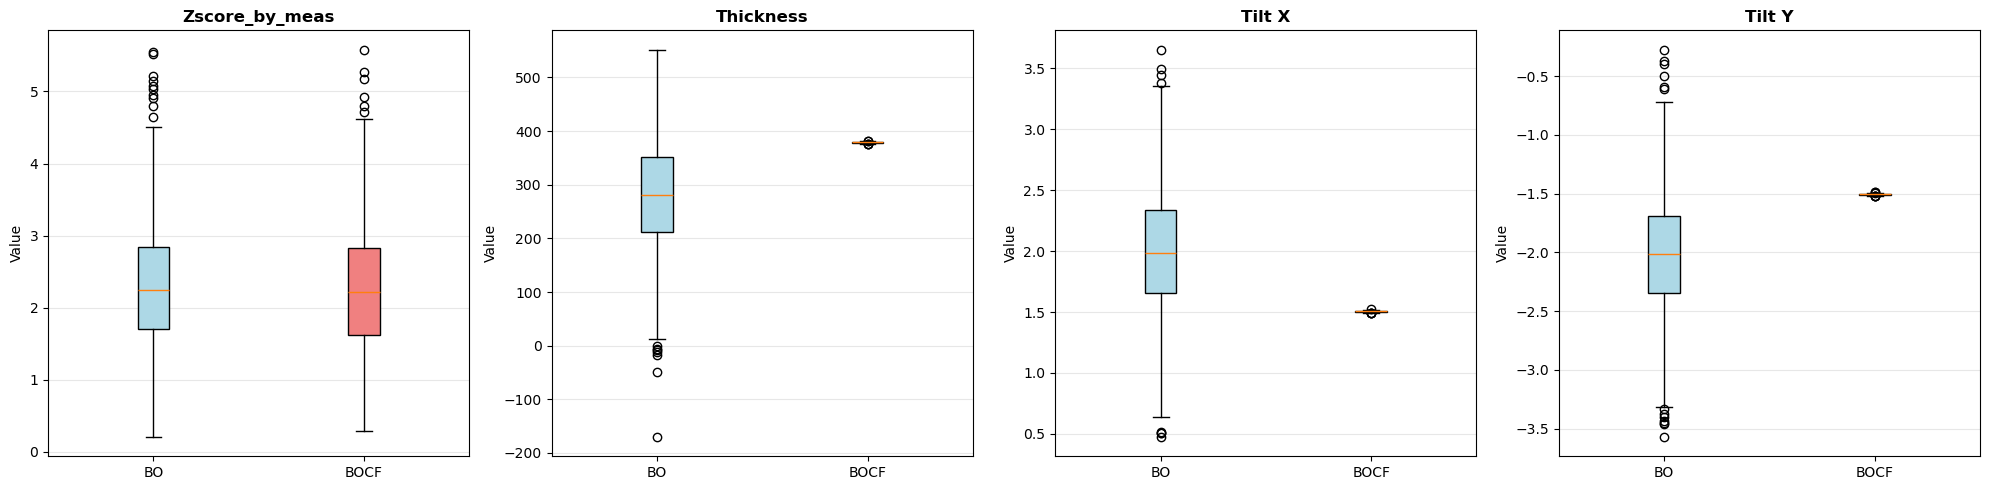

In [62]:
import matplotlib.pyplot as plt

# Component names
component_names = ['Zscore_by_meas', 'Thickness', 'Tilt X', 'Tilt Y']

# Create figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Create box plots for each component
for i, (ax, name) in enumerate(zip(axes, component_names)):
    # Prepare data for box plot
    data = [BO_data[:, i].numpy(), BOCF_data[:, i].numpy()]
    
    # Create box plot
    bp = ax.boxplot(data, tick_labels=['BO', 'BOCF'], patch_artist=True)
    
    # Customize colors
    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    # Set title and labels
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Value', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

# Adjust layout
plt.tight_layout()
plt.show()